In [2]:
library(dplyr)
library(stringr)
library(ggplot2)

In [ ]:
## Load required ratio study functions
cov <- function(df_col) {
    mean_ratio <- mean(df_col, na.rm = TRUE)
    sd_ratio <- sd(df_col, na.rm = TRUE)
    cov_value <- (sd_ratio / mean_ratio) * 100
    return(cov_value)
}


In [4]:
prb = function(df_sp,df_sr) {
    valid <- !is.na(df_sp) & !is.na(df_sr)
    df_sp <- df_sp[valid]
    df_sr <- df_sr[valid]
    if (length(df_sr) < 2) {
        return(NA)
    }
    model <- lm(df_sr ~ df_sp)
    
    # PRB is the slope of the regression model
    prb <- coef(model)[2]
    return(prb)
}

In [5]:
cod = function(df_col) {
    median_ratio <- median(df_col, na.rm = TRUE)
    cod <- mean(abs(df_col - median_ratio), na.rm = TRUE) / median_ratio * 100
    
    return(cod)
}

In [6]:
prd = function(df_av,df_sp,df_sr) {
mean_ratio = mean(df_sr, na.rm = TRUE)
weighted_mean_ratio = sum(df_av, na.rm = TRUE) / sum(df_sp, na.rm = TRUE)
prd = mean_ratio / weighted_mean_ratio
return (prd)
}

In [ ]:
## Load ag dataframes
ag22 = read.csv('tippecanoe/Ag_Sales_2022.csv')
ag23 = read.csv('tippecanoe/Ag_Sales_2023.csv')
ag24 = read.csv('tippecanoe/Ag_Sales_2024.csv')

In [ ]:
#Filter out unwanted sales (correct property class, non-low sale price, and non-investment land as specified by price per acre)
ag22 = ag22[(ag22$PropertyClass == 100 | ag22$PropertyClass == 120) & ag22$SalePrice > 10000 & ag22$PPA < 16000,]
ag23 = ag23[(ag23$PropertyClass == 100 | ag23$PropertyClass == 120) & ag23$SalePrice > 10000 & ag23$PPA < 16000,]
ag24 = ag24[(ag24$PropertyClass == 100 | ag24$PropertyClass == 120) & ag24$SalePrice > 10000 & ag24$PPA < 16000,]

In [ ]:
# Find sales that deviate significantly from the expected sale ratio for that year, and trim 10% of outlying sales
mad_x = median(abs(ag22$SaleRatio - 0.14), na.rm = TRUE)
mod_z <- 0.6745 * (ag22$SaleRatio - 0.14) / mad_x
threshold <- quantile(abs(mod_z), 0.9, na.rm = TRUE)
ag22o = ag22[abs(mod_z) > threshold, ]
ag22 <- ag22[abs(mod_z) <= threshold, ]
mad_x = median(abs(ag23$SaleRatio - 0.17), na.rm = TRUE)
mod_z <- 0.6745 * (ag23$SaleRatio - 0.17) / mad_x
threshold <- quantile(abs(mod_z), 0.9, na.rm = TRUE)
ag23o = ag23[abs(mod_z) > threshold, ]
ag23 <- ag23[abs(mod_z) <= threshold, ]
mad_x = median(abs(ag24$SaleRatio - 0.19), na.rm = TRUE)
mod_z <- 0.6745 * (ag24$SaleRatio - 0.19) / mad_x
threshold <- quantile(abs(mod_z), 0.9, na.rm = TRUE)
ag24o = ag24[abs(mod_z) > threshold, ]
ag24 <- ag24[abs(mod_z) <= threshold, ]

In [ ]:
## Combined all outliers for study
agoutliers = rbind(ag22o,ag23o,ag24o)

In [ ]:
## Make sure Zip codes are valid
ag22$Zip = as.numeric(ag22$Zip)
ag23$Zip = as.numeric(ag23$Zip)
ag24$Zip = as.numeric(ag24$Zip)
agoutliers$Zip = as.numeric(agoutliers$Zip)
ag22 = ag22[!is.na(ag22$Zip),]
ag23 = ag23[!is.na(ag23$Zip),]
ag24 = ag24[!is.na(ag24$Zip),]
agoutliers = agoutliers[!is.na(agoutliers$Zip),]
ag22$Zip = as.character(ag22$Zip)
ag23$Zip = as.character(ag23$Zip)
ag24$Zip = as.character(ag24$Zip)
agoutliers$Zip = as.character(agoutliers$Zip)

In [ ]:
## Combined all valid ag sales for study
totalag = rbind(ag22,ag23,ag24)
median(totalag$SaleRatio)
cod(totalag$SaleRatio)

[1] 0.1219251

[1] 57.06932

# Ag Sales Study

In [ ]:
nrow(agoutliers)
round(((table(agoutliers$PropertyClass) / nrow(agoutliers)) * 100),2)
round(((table(totalag$PropertyClass) / nrow(totalag)) * 100),2)

[1] 1009


  100   120 
98.12  1.88 


 100  120 
98.6  1.4 

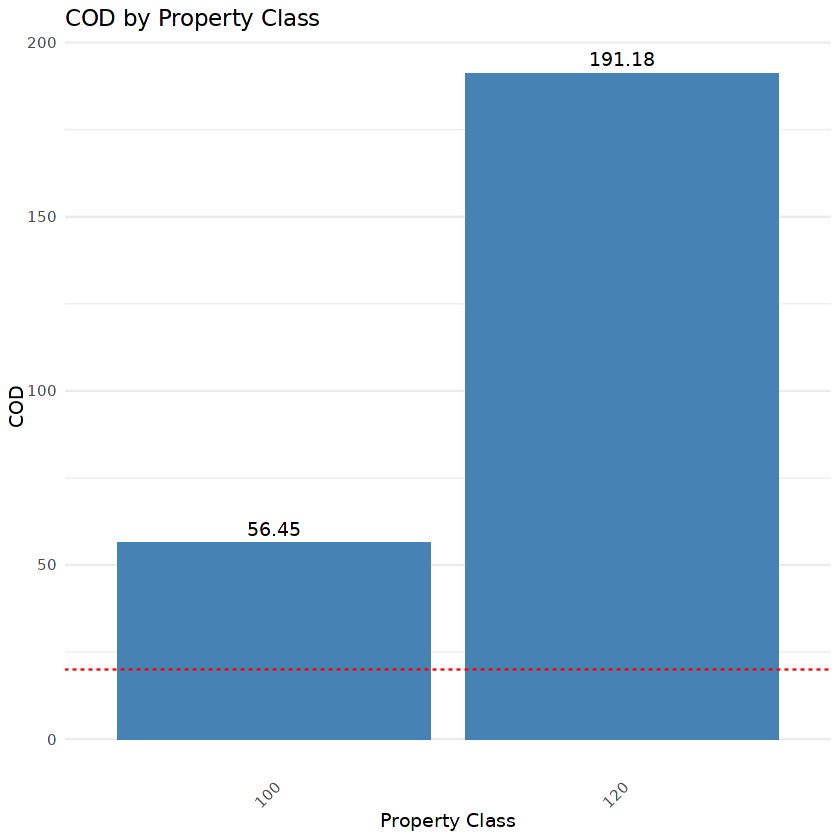

In [ ]:
## COD by property class
pclass <- totalag %>%
  group_by(PropertyClass) %>%
  summarize(COD = cod(SaleRatio), Count = n())

pclass <- pclass %>%
  mutate(PropertyClass = factor(PropertyClass, levels = unique(PropertyClass)))

ggplot(pclass[pclass$Count > 5,], aes(x = PropertyClass, y = COD)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = 20, linetype = "dashed", color = "red") +
  labs(
    title = "COD by Property Class",
    x = "Property Class",
    y = "COD"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.x = element_blank()
  ) + 
  geom_text(aes(label = round(COD, 2)), vjust = -0.5)

`summarise()` has grouped output by 'PriceBucket'. You can override using the
`.groups` argument.


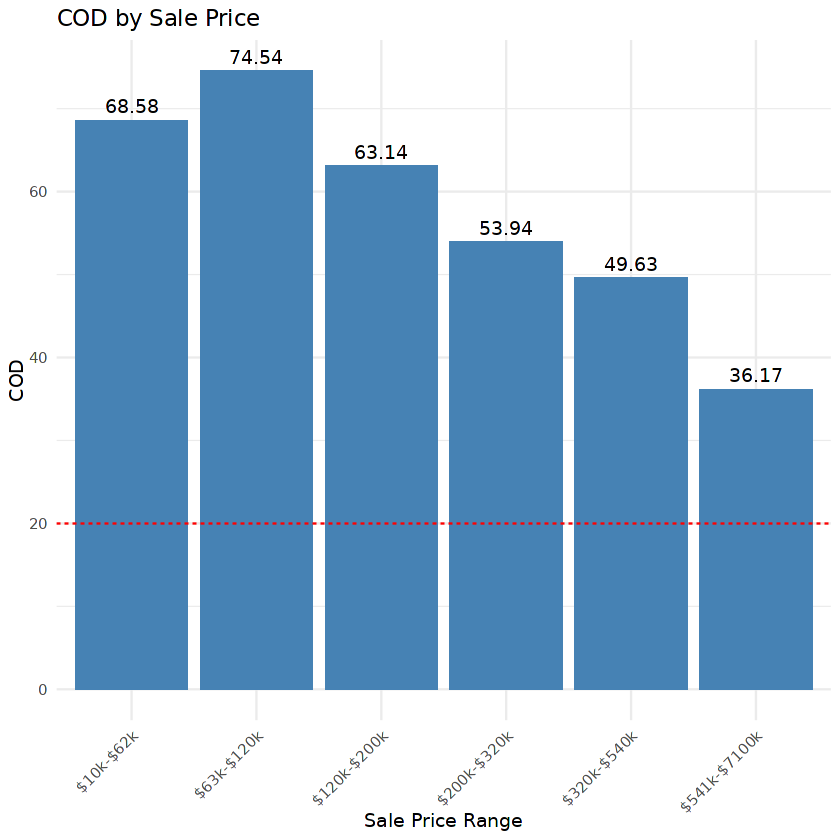

In [ ]:
## COD by sale price
saleprice <- totalag %>%
  mutate(
    PriceBucket = cut(
      SalePrice,
      breaks = quantile(SalePrice, probs = seq(0, 1, length.out = 7), na.rm = TRUE),
      include.lowest = TRUE,
      labels = FALSE
    )
  )

bucket_labels <- saleprice %>%
  group_by(PriceBucket) %>%
  summarize(
    MinPrice = min(SalePrice, na.rm = TRUE),
    MaxPrice = max(SalePrice, na.rm = TRUE)
  ) %>%
  mutate(Label = paste0("$", round(MinPrice/1000), "k-$", round(MaxPrice/1000), "k"))

saleprice <- saleprice %>%
  left_join(bucket_labels %>% select(PriceBucket, Label), by = "PriceBucket")

salesummary <- saleprice %>%
  group_by(PriceBucket, Label) %>%
  summarize(COD = cod(SaleRatio)) %>%
  ungroup() %>%
  arrange(PriceBucket) %>%
  mutate(Label = factor(Label, levels = unique(Label)))


ggplot(salesummary, aes(x = Label, y = COD)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = 20, linetype = "dashed", color = "red") +
  labs(
    title = "COD by Sale Price",
    x = "Sale Price Range",
    y = "COD"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  geom_text(aes(label = round(COD, 2)), vjust = -0.5)

`summarise()` has grouped output by 'AcreBucket'. You can override using the
`.groups` argument.


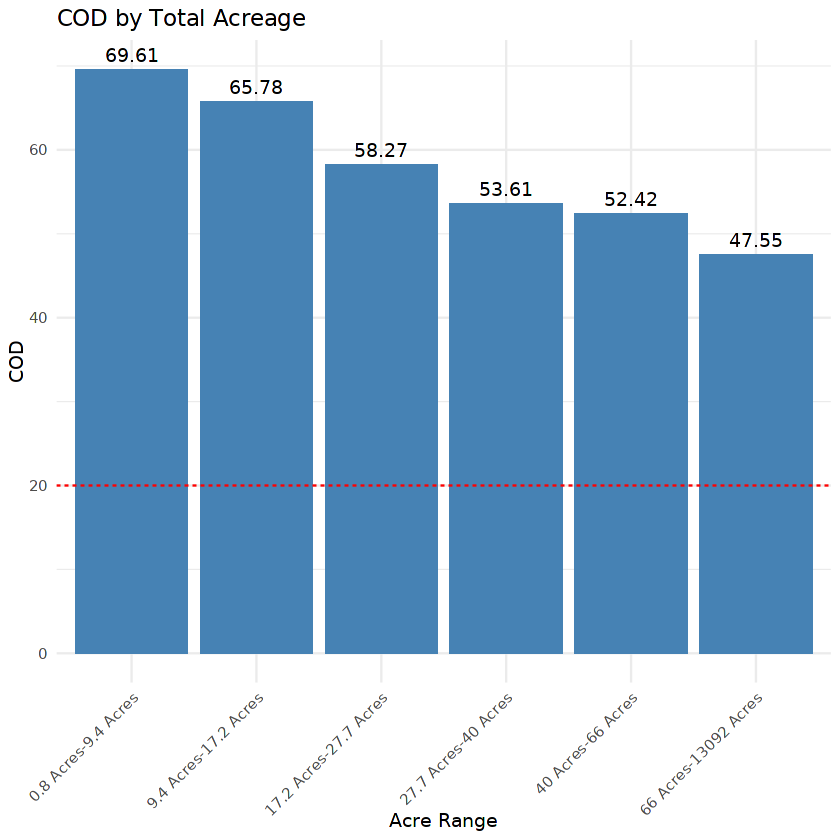

In [ ]:
## COD by total acreage
acre <- totalag %>%
  mutate(
    AcreBucket = cut(
      Acre,
      breaks = quantile(Acre, probs = seq(0, 1, length.out = 7), na.rm = TRUE),
      include.lowest = TRUE,
      labels = FALSE
    )
  )

bucket_labels <- acre %>%
  group_by(AcreBucket) %>%
  summarize(
    MinAcre = min(Acre, na.rm = TRUE),
    MaxAcre = max(Acre, na.rm = TRUE)
  ) %>%
  mutate(Label = paste0(round(MinAcre,1), " Acres-", round(MaxAcre,1), " Acres"))

acre <- acre %>%
  left_join(bucket_labels %>% select(AcreBucket, Label), by = "AcreBucket")

acresummary <- acre %>%
  group_by(AcreBucket, Label) %>%
  summarize(COD = cod(SaleRatio)) %>%
  ungroup() %>%
  arrange(AcreBucket) %>%
  mutate(Label = factor(Label, levels = unique(Label)))
  
ggplot(acresummary, aes(x = Label, y = COD)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = 20, linetype = "dashed", color = "red") +
  labs(
    title = "COD by Total Acreage",
    x = "Acre Range",
    y = "COD"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  geom_text(aes(label = round(COD, 2)), vjust = -0.5)

`summarise()` has grouped output by 'AVBucket'. You can override using the
`.groups` argument.


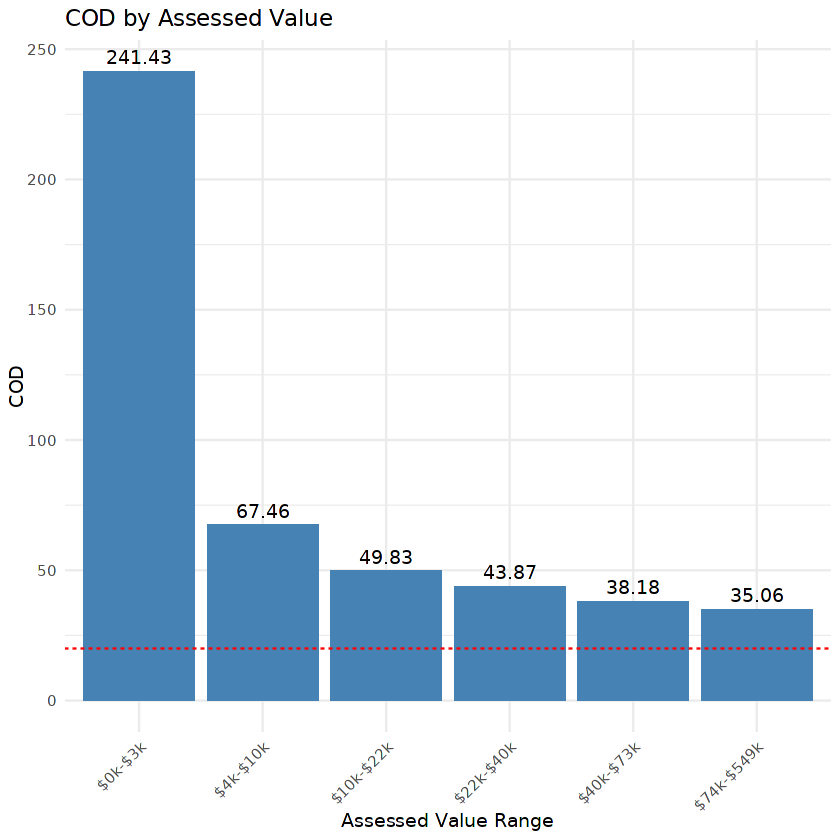

In [ ]:
## COD by assessed value
av <- totalag %>%
  mutate(
    AVBucket = cut(
      TotalAV,
      breaks = quantile(TotalAV, probs = seq(0, 1, length.out = 7), na.rm = TRUE),
      include.lowest = TRUE,
      labels = FALSE
    )
  )

bucket_labels <- av %>%
  group_by(AVBucket) %>%
  summarize(
    MinAV = min(TotalAV, na.rm = TRUE),
    MaxAV = max(TotalAV, na.rm = TRUE)
  ) %>%
  mutate(Label = paste0("$", round(MinAV/1000), "k-$", round(MaxAV/1000), "k"))

av <- av %>%
  left_join(bucket_labels %>% select(AVBucket, Label), by = "AVBucket")

avsummary <- av %>%
  group_by(AVBucket, Label) %>%
  summarize(COD = cod(SaleRatio)) %>%
  ungroup() %>%
  arrange(AVBucket) %>%
  mutate(Label = factor(Label, levels = unique(Label)))

ggplot(avsummary, aes(x = Label, y = COD)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = 20, linetype = "dashed", color = "red") +
  labs(
    title = "COD by Assessed Value",
    x = "Assessed Value Range",
    y = "COD"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  geom_text(aes(label = round(COD, 2)), vjust = -0.5)

`summarise()` has grouped output by 'PPABucket'. You can override using the
`.groups` argument.


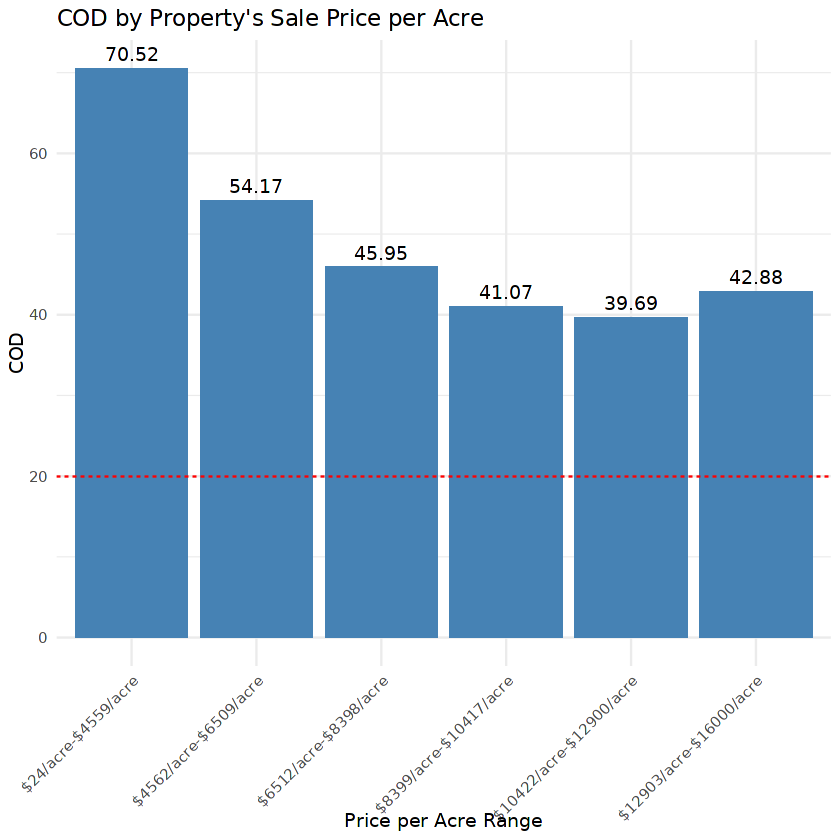

In [ ]:
#COD by Sale Price per Acre
ppa <- totalag %>%
  mutate(
    PPABucket = cut(
      PPA,
      breaks = quantile(PPA, probs = seq(0, 1, length.out = 7), na.rm = TRUE),
      include.lowest = TRUE,
      labels = FALSE
    )
  )

bucket_labels <- ppa %>%
  group_by(PPABucket) %>%
  summarize(
    MinPPA = min(PPA, na.rm = TRUE),
    MaxPPA = max(PPA, na.rm = TRUE)
  ) %>%
  mutate(Label = paste0("$", round(MinPPA), "/acre-$", round(MaxPPA), "/acre"))

ppa <- ppa %>%
  left_join(bucket_labels %>% select(PPABucket, Label), by = "PPABucket")

ppasummary <- ppa %>%
  group_by(PPABucket, Label) %>%
  summarize(COD = cod(SaleRatio)) %>%
  ungroup() %>%
  arrange(PPABucket) %>%
  mutate(Label = factor(Label, levels = unique(Label)))


ggplot(ppasummary, aes(x = Label, y = COD)) +
  geom_col(fill = "steelblue") +
  geom_hline(yintercept = 20, linetype = "dashed", color = "red") +
  labs(
    title = "COD by Property's Sale Price per Acre",
    x = "Price per Acre Range",
    y = "COD"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  geom_text(aes(label = round(COD, 2)), vjust = -0.5)

In [ ]:
median(ag22$SaleRatio[ag22$PropertyClass == 100])
cod(ag22$SaleRatio[ag22$PropertyClass == 100])
median(ag22$SaleRatio[ag22$PropertyClass != 100])
cod(ag22$SaleRatio[ag22$PropertyClass != 100])
#ag22 = ag22[ag22$PropertyClass != 101 & ag22$PropertyClass != 199,]

[1] 0.1122159

[1] 56.5424

[1] 0.032

[1] 142.7914

In [ ]:
mr = median(ag22$SaleRatio,na.rm=TRUE)
mr
ag22$Deviation = abs(ag22$SaleRatio - mr)
nrow(ag22[ag22$Deviation > 0.11,]) / nrow(ag22)

[1] 0.1116667

[1] 0.1702991

In [ ]:
ag22$Zip = as.numeric(ag22$Zip)
ag23$Zip = as.numeric(ag23$Zip)
ag24$Zip = as.numeric(ag24$Zip)

In [ ]:
class = read.csv('tippecanoe/Parcel_Classifications_2023.csv')

In [ ]:
class = class %>%
group_by(Zip,County) %>%
summarise(Zip = first(Zip),County = first(County),ZipClassification = first(ZipClassification))
head(class)
nrow(class)

`summarise()` has grouped output by 'Zip'. You can override using the `.groups`
argument.


Zip,County,ZipClassification
<int>,<chr>,<chr>
40026,Clark,Urban
40059,Clark,Urban
40202,Clark,Urban
40212,Clark,Urban
40212,Floyd,Urban
40222,Clark,Urban


[1] 1275

In [ ]:
nrow(ag22)
colnames(ag22)
ag22 = inner_join(ag22,class,by=c('Zip'='Zip','County'='County'),relationship='many-to-many')
nrow(ag22)

[1] 4680

[1] "X"             "SaleID"        "ParcelNumber"  "Address"      
 [5] "City"          "TotalAV"       "PropertyClass" "Neighborhood" 
 [9] "TaxDistrict"   "Acre"          "SalePrice"     "County"       
[13] "SaleRatio"     "PPA"           "State"         "Zip"          
[17] "Deviation"

[1] 4626

In [ ]:
nrow(ag23)
ag23 = inner_join(ag23,class,by=c('Zip'='Zip','County'='County'),relationship='many-to-many')
nrow(ag23)

[1] 3820

[1] 3783

In [ ]:
nrow(ag24)
ag24 = inner_join(ag24,class,by=c('Zip'='Zip','County'='County'),relationship='many-to-many')
nrow(ag24)

[1] 851

[1] 847

In [ ]:
ag22u = ag22[ag22$ZipClassification == 'Urban',]
ag23u = ag23[ag23$ZipClassification == 'Urban',]
ag24u = ag24[ag24$ZipClassification == 'Urban',]
ag22r = ag22[ag22$ZipClassification == 'Rural',]
ag23r = ag23[ag23$ZipClassification == 'Rural',]
ag24r = ag24[ag24$ZipClassification == 'Rural',]

In [ ]:
median = round(median(ag22u$SaleRatio,na.rm=TRUE),2)
cod2 = round(cod(ag22u$SaleRatio),2)
cov2 = round(cov(ag22u$SaleRatio),2)
prd2 = round(prd(ag22u$TotalAV,ag22u$SalePrice,ag22u$SaleRatio),2)
prb2 = round(prb(ag22u$SalePrice,ag22u$SaleRatio),2)
print(paste('2022 Urban Ag Land: Median:',median,'COD:',cod2,'COV:',cov2,'PRD:',prd2,'PRB:',prb2,
            'with',nrow(ag22u),'sales'))
median = round(median(ag22r$SaleRatio,na.rm=TRUE),2)
cod2 = round(cod(ag22r$SaleRatio),2)
cov2 = round(cov(ag22r$SaleRatio),2)
prd2 = round(prd(ag22r$TotalAV,ag22r$SalePrice,ag22r$SaleRatio),2)
prb2 = round(prb(ag22r$SalePrice,ag22r$SaleRatio),2)
print(paste('2022 Rural Ag Land: Median:',median,'COD:',cod2,'COV:',cov2,'PRD:',prd2,'PRB:',prb2,
            'with',nrow(ag22r),'sales'))

[1] "2022 Urban Ag Land: Median: 0.11 COD: 60.44 COV: 70.98 PRD: 1.12 PRB: 0 with 899 sales"
[1] "2022 Rural Ag Land: Median: 0.11 COD: 56.35 COV: 68.01 PRD: 1.04 PRB: 0 with 3727 sales"


In [ ]:
median = round(median(ag23u$SaleRatio,na.rm=TRUE),2)
cod2 = round(cod(ag23u$SaleRatio),2)
cov2 = round(cov(ag23u$SaleRatio),2)
prd2 = round(prd(ag23u$TotalAV,ag23u$SalePrice,ag23u$SaleRatio),2)
prb2 = round(prb(ag23u$SalePrice,ag23u$SaleRatio),2)
print(paste('2023 Urban Ag Land: Median:',median,'COD:',cod2,'COV:',cov2,'PRD:',prd2,'PRB:',prb2,
            'with',nrow(ag23u),'sales'))
median = round(median(ag23r$SaleRatio,na.rm=TRUE),2)
cod2 = round(cod(ag23r$SaleRatio),2)
cov2 = round(cov(ag23r$SaleRatio),2)
prd2 = round(prd(ag23r$TotalAV,ag23r$SalePrice,ag23r$SaleRatio),2)
prb2 = round(prb(ag23r$SalePrice,ag23r$SaleRatio),2)
print(paste('2023 Rural Ag Land: Median:',median,'COD:',cod2,'COV:',cov2,'PRD:',prd2,'PRB:',prb2,
            'with',nrow(ag23r),'sales'))

[1] "2023 Urban Ag Land: Median: 0.13 COD: 61.71 COV: 71.71 PRD: 1.05 PRB: 0 with 673 sales"
[1] "2023 Rural Ag Land: Median: 0.13 COD: 56.27 COV: 68.19 PRD: 1.02 PRB: 0 with 3110 sales"


In [ ]:
median = round(median(ag24u$SaleRatio,na.rm=TRUE),2)
cod2 = round(cod(ag24u$SaleRatio),2)
cov2 = round(cov(ag24u$SaleRatio),2)
prd2 = round(prd(ag24u$TotalAV,ag24u$SalePrice,ag24u$SaleRatio),2)
prb2 = round(prb(ag24u$SalePrice,ag24u$SaleRatio),2)
print(paste('2024 Urban Ag Land: Median:',median,'COD:',cod2,'COV:',cov2,'PRD:',prd2,'PRB:',prb2,
            'with',nrow(ag24u),'sales'))
median = round(median(ag24r$SaleRatio,na.rm=TRUE),2)
cod2 = round(cod(ag24r$SaleRatio),2)
cov2 = round(cov(ag24r$SaleRatio),2)
prd2 = round(prd(ag24r$TotalAV,ag24r$SalePrice,ag24r$SaleRatio),2)
prb2 = round(prb(ag24r$SalePrice,ag24r$SaleRatio),2)
print(paste('2024 Rural Ag Land: Median:',median,'COD:',cod2,'COV:',cov2,'PRD:',prd2,'PRB:',prb2,
            'with',nrow(ag24r),'sales'))

[1] "2024 Urban Ag Land: Median: 0.15 COD: 48.31 COV: 62.14 PRD: 1.13 PRB: 0 with 186 sales"
[1] "2024 Rural Ag Land: Median: 0.15 COD: 49.68 COV: 62.06 PRD: 1.01 PRB: 0 with 661 sales"
